In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load Dataset
# Replace 'Advertising.csv' with your actual local file path
df = pd.read_csv('Advertising.csv')
df = df.drop(columns=['Unnamed: 0'], errors='ignore')

# 2. Describe
print("--- Data Info ---")
print(df.info())
print("\n--- Statistical Summary ---")
print(df.describe())

--- Data Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

--- Statistical Summary ---
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   14.022500
std     85.854236   14.846809   21.778621    5.217457
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   10.375000
50%    149.750000   22.900000   25.750000   12.900000
75%    218.825000   36.525000   45.100000   17.400000
max    296.400000   49.600000  114.000000   27.000000


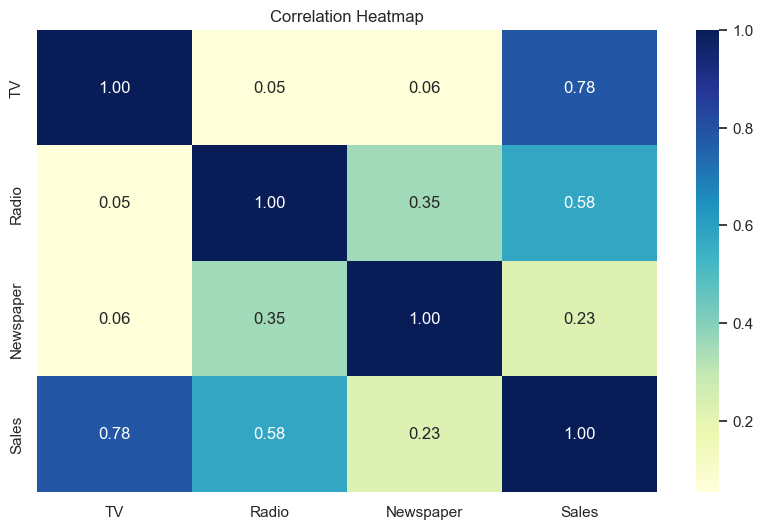

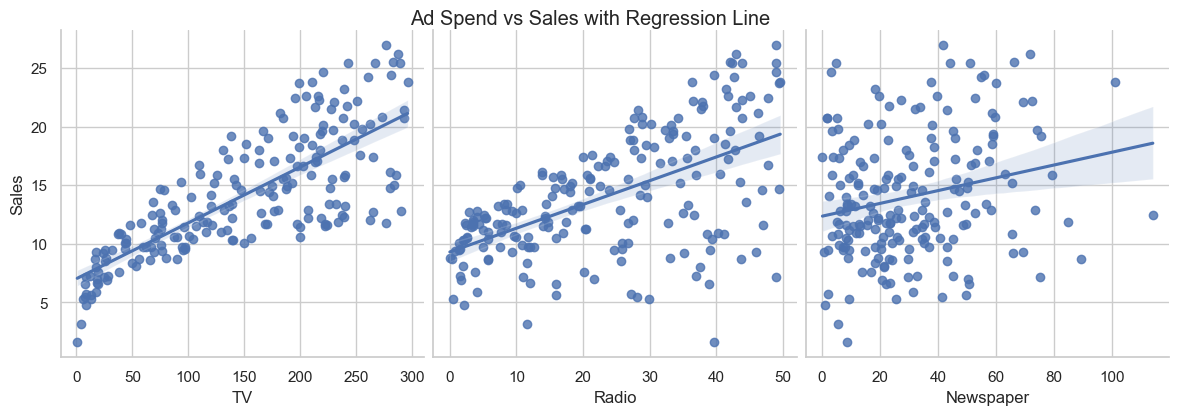

In [2]:
# Set visual style
sns.set_theme(style="whitegrid")

# Heatmap for Correlation
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

# Pairplot to see linearity
sns.pairplot(df, x_vars=['TV', 'Radio', 'Newspaper'], y_vars='Sales', height=4, aspect=1, kind='reg')
plt.suptitle('Ad Spend vs Sales with Regression Line', y=1.02)
plt.show()


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# A. Advanced Feature Engineering (Synergy between TV and Radio)
df['TV_Radio_Synergy'] = df['TV'] * df['Radio']

# B. Split Data
X = df[['TV', 'Radio', 'Newspaper', 'TV_Radio_Synergy']]
y = df['Sales']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# C. Scaling (Essential for comparing feature importance)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# D. Build Advanced Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

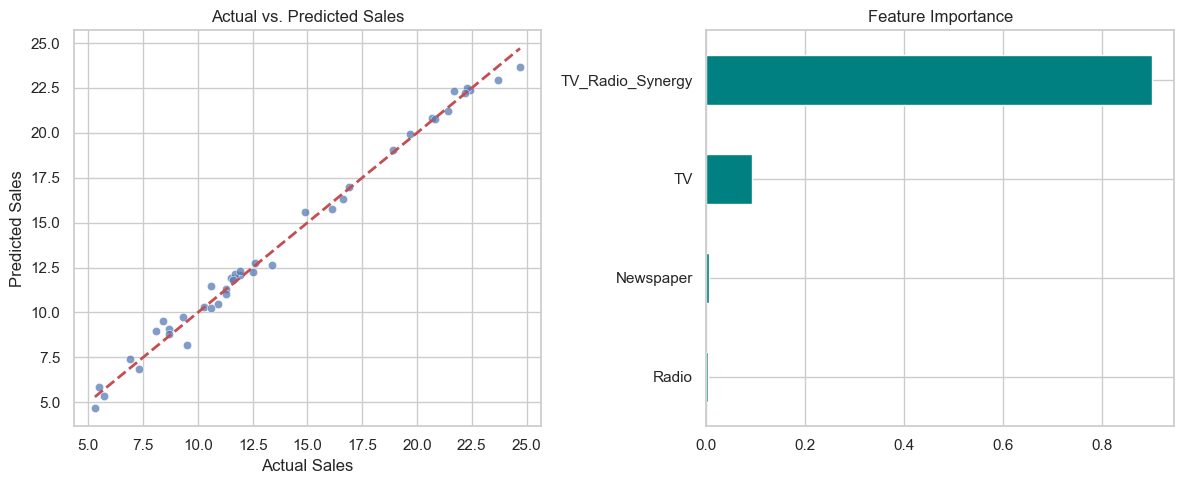

In [4]:
# Predictions
y_pred = model.predict(X_test_scaled)

plt.figure(figsize=(12, 5))

# 1. Actual vs Predicted
plt.subplot(1, 2, 1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
plt.title('Actual vs. Predicted Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')

# 2. Feature Importance
plt.subplot(1, 2, 2)
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance')

plt.tight_layout()
plt.show()


In [5]:
def predict_sales(tv, radio, newspaper):
    # 1. Calculate the 4th feature (Synergy) that your scaler is expecting
    synergy = tv * radio
    
    # 2. Create the DataFrame with all 4 columns in the correct order
    input_df = pd.DataFrame(
        [[tv, radio, newspaper, synergy]], 
        columns=['TV', 'Radio', 'Newspaper', 'TV_Radio_Synergy']
    )
    
    # 3. Scale and Predict
    scaled_data = scaler.transform(input_df)
    prediction = model.predict(scaled_data)
    
    return prediction[0]


In [6]:
# 1. Define the scenarios (Needed so the loop knows what to process)
test_scenarios = [
    {"TV": 200, "Radio": 40, "News": 10, "Label": "Standard Strategy"},
    {"TV": 100, "Radio": 80, "News": 50, "Label": "Balanced Strategy"},
    {"TV": 20,  "Radio": 10, "News": 200, "Label": "Newspaper Focused"},
    {"TV": 0,   "Radio": 0,  "News": 0,   "Label": "No Advertising"}
]

# 2. Identify Baseline (Base Sales)
base_sales = predict_sales(0, 0, 0)

# 3. Print the Results
print("="*55)
print("      ADVANCED SALES FORECAST ANALYSIS       ")
print("="*55)

for scenario in test_scenarios:
    # Calculate Metrics
    prediction = predict_sales(scenario['TV'], scenario['Radio'], scenario['News'])
    synergy_value = scenario['TV'] * scenario['Radio']
    total_spend = scenario['TV'] + scenario['Radio'] + scenario['News']
    
    # Calculate 'Lift'
    lift = prediction - base_sales if prediction > base_sales else 0
    
    # Print Formatted Block
    print(f"\n▶ STRATEGY: {scenario['Label'].upper()}")
    print(f"   Budget: TV(${scenario['TV']}) | Radio(${scenario['Radio']}) | News(${scenario['News']})")
    print(f"   Total Investment:  ${total_spend:<8}")
    print(f"   Synergy Impact:    {synergy_value:<8}")
    print(f"   " + "-"*35)
    
    if scenario['Label'] == "No Advertising":
        print(f"   BASELINE ORGANIC SALES: {prediction:.2f} units")
    else:
        print(f"    FORECASTED TOTAL SALES: {prediction:.2f} units")
        print(f"     AD-DRIVEN LIFT:        +{lift:.2f} units")

print("\n" + "="*55)
print(f"NOTE: Baseline Sales ({base_sales:.2f}) is the predicted")
print("performance without any marketing intervention.")
print("="*55)


      ADVANCED SALES FORECAST ANALYSIS       

▶ STRATEGY: STANDARD STRATEGY
   Budget: TV($200) | Radio($40) | News($10)
   Total Investment:  $250     
   Synergy Impact:    8000    
   -----------------------------------
    FORECASTED TOTAL SALES: 20.65 units
     AD-DRIVEN LIFT:        +17.59 units

▶ STRATEGY: BALANCED STRATEGY
   Budget: TV($100) | Radio($80) | News($50)
   Total Investment:  $230     
   Synergy Impact:    8000    
   -----------------------------------
    FORECASTED TOTAL SALES: 20.73 units
     AD-DRIVEN LIFT:        +17.68 units

▶ STRATEGY: NEWSPAPER FOCUSED
   Budget: TV($20) | Radio($10) | News($200)
   Total Investment:  $230     
   Synergy Impact:    200     
   -----------------------------------
    FORECASTED TOTAL SALES: 6.69 units
     AD-DRIVEN LIFT:        +3.64 units

▶ STRATEGY: NO ADVERTISING
   Budget: TV($0) | Radio($0) | News($0)
   Total Investment:  $0       
   Synergy Impact:    0       
   -----------------------------------
   BASEL